# 5 · Deep SVDD — Architecture Search & Ablation (P-only)


## Experiments

| # | What we vary | Purpose |
|---|-------------|---------|
| 1 | Spread regularisation λ | Can `loss - λ·std(z)` prevent collapse? |
| 2 | Momentum centre update | Does a moving centre slow collapse? |
| 3 | Freezing strategy | How many encoder layers to fine-tune? |
| 4 | Head architecture | Depth, dropout — simpler head = harder to collapse? |
| 5 | Bottleneck dimension | Smaller dim = fewer paths to trivial solution? |
| 6 | Training hyperparameters | LR, weight decay, batch size |
| 7 | Preprocessing | CLAHE vs none on W-only |
| 8 | Cross-entropy noise reg (Chong et al., 2021) | Inject Gaussian noise as negatives — CE loss prevents collapse |
| 9 | Adaptive weighting (Chong et al., 2021) | α_t = SVDD_loss / reg_loss — removes need to hand-tune α |

In [ ]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

import src.dataset as _ds; importlib.reload(_ds)
import src.models  as _md; importlib.reload(_md)
from src.dataset     import build_image_index, CrackDataset, load_splits, save_splits
from src.models      import DeepSVDD, DeepSVDDWithSE
from src.train_utils import eval_scores, calibrate_threshold, compute_metrics, print_metrics
from src.viz_utils   import plot_bar_ablation
from sklearn.model_selection import train_test_split


DATASET_DIR  = 'SDNET2018'
SPLITS_DIR   = 'splits'
RESULTS_DIR  = 'results'
CKPT_DIR     = 'checkpoints'
SURFACE      = 'P'          
RANDOM_STATE = 42
BATCH_SIZE   = 64
QUICK_EPOCHS = 8            # fast sweep — enough to detect collapse
NUM_WORKERS  = 0

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'Surface: {SURFACE} (Pavement only)')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,    exist_ok=True)

Device : cuda
Surface: P (Pavement only)


In [3]:
splits_exist = all(
    os.path.exists(os.path.join(SPLITS_DIR, f'patch_index_{s}.pkl'))
    for s in ('train', 'val', 'test')
)

if splits_exist:
    train_records, val_records, test_records = load_splits(SPLITS_DIR)
    print('Loaded existing P-only splits.')
else:
    print('Regenerating P-only splits...')
    all_records = build_image_index(DATASET_DIR, surface_types=[SURFACE])
    labels_all  = np.array([r['label'] for r in all_records])
    train_records, temp = train_test_split(
        all_records, test_size=0.30, stratify=labels_all, random_state=RANDOM_STATE)
    temp_labels = np.array([r['label'] for r in temp])
    val_records, test_records = train_test_split(
        temp, test_size=0.50, stratify=temp_labels, random_state=RANDOM_STATE)
    save_splits(train_records, val_records, test_records, SPLITS_DIR)

def make_loaders(preprocessing='clahe', batch_size=BATCH_SIZE):
    """Train (normal-only) + val DataLoaders for a given preprocessing."""
    tr = CrackDataset(train_records, preprocessing=preprocessing,
                      augment=True, normal_only=True)
    va = CrackDataset(val_records,   preprocessing=preprocessing)
    return (
        DataLoader(tr, batch_size=batch_size, shuffle=True,  num_workers=NUM_WORKERS),
        DataLoader(va, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS),
    )

train_loader, val_loader = make_loaders('clahe')
print(f'Train (normal only): {len(train_loader.dataset):,}')
print(f'Val               : {len(val_loader.dataset):,}')

Loaded existing P-only splits.
Train (normal only): 15,207
Val               : 3,650


In [4]:
def _freeze_bn(model):
    
    for m in model.encoder.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()
            m.weight.requires_grad_(False)   # freeze γ
            m.bias.requires_grad_(False)     # freeze β (acts as bias — collapse risk)


def quick_train_eval(
    model, tr_loader, va_loader,
    lr=1e-4, wd=1e-4,
    n_epochs=QUICK_EPOCHS,
    scheduler_type='cosine',
    device=DEVICE,
) -> float:
    
    model.init_centre(tr_loader, device)
    _freeze_bn(model)
    opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                     lr=lr, weight_decay=wd)
    if scheduler_type == 'cosine':
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    else:
        sched = None

    best_auroc = 0.0
    for epoch in range(n_epochs):
        model.train()
        _freeze_bn(model)   # re-apply after model.train() resets BN to train mode
        for x, _ in tr_loader:
            x = x.to(device)
            z = model(x)
            loss = ((z - model.centre) ** 2).sum(dim=1).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        if sched: sched.step()

        scores, labels = eval_scores(model, va_loader, device)
        auroc = roc_auc_score(labels, scores)
        best_auroc = max(best_auroc, auroc)
    return best_auroc


def quick_train_eval_spread(
    model, tr_loader, va_loader,
    lam=0.1, lr=1e-4, wd=1e-4,
    n_epochs=QUICK_EPOCHS,
    device=DEVICE,
) -> float:
    
    model.init_centre(tr_loader, device)
    _freeze_bn(model)
    opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                     lr=lr, weight_decay=wd)

    best_auroc = 0.0
    for epoch in range(n_epochs):
        model.train()
        _freeze_bn(model)   # re-apply after model.train()
        for x, _ in tr_loader:
            x = x.to(device)
            z = model(x)
            svdd_loss = ((z - model.centre) ** 2).sum(dim=1).mean()
            spread    = z.std(dim=0).mean()
            loss      = svdd_loss - lam * spread
            opt.zero_grad(); loss.backward(); opt.step()
        scores, labels = eval_scores(model, va_loader, device)
        auroc = roc_auc_score(labels, scores)
        best_auroc = max(best_auroc, auroc)
    return best_auroc


def quick_train_eval_momentum(
    model, tr_loader, va_loader,
    momentum=0.99, lr=1e-4, wd=1e-4,
    n_epochs=QUICK_EPOCHS,
    device=DEVICE,
) -> float:
    
    model.init_centre(tr_loader, device)
    _freeze_bn(model)
    opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                     lr=lr, weight_decay=wd)

    best_auroc = 0.0
    for epoch in range(n_epochs):
        model.train()
        _freeze_bn(model)   # re-apply after model.train()
        for x, _ in tr_loader:
            x = x.to(device)
            z = model(x)
            loss = ((z - model.centre) ** 2).sum(dim=1).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            with torch.no_grad():
                batch_mean = z.mean(dim=0)
                model.centre.mul_(momentum).add_((1 - momentum) * batch_mean)
        scores, labels = eval_scores(model, va_loader, device)
        auroc = roc_auc_score(labels, scores)
        best_auroc = max(best_auroc, auroc)
    return best_auroc




## Experiment 1 — Spread Regularisation

Loss: `||phi(x) - c||² - λ · std(z)`

The `std` term penalises low variance — if weights→0, all outputs→0, std→0, penalty→large. Should resist collapse.

Experiment 1: Spread Regularisation (fixed model, W-only)
  λ=0.0 = standard SVDD loss (baseline)



init_centre: 100%|██████████| 238/238 [01:08<00:00,  3.48it/s]


  Centre initialised — mean norm: 1.4515
  λ=0.00  AUROC=0.6307


init_centre: 100%|██████████| 238/238 [01:08<00:00,  3.50it/s]


  Centre initialised — mean norm: 1.4433
  λ=0.01  AUROC=0.6406


...

  Centre initialised — mean norm: 1.3704
  λ=0.10  AUROC=0.6718


init_centre: 100%|██████████| 238/238 [01:08<00:00,  3.49it/s]


  Centre initialised — mean norm: 1.5748
  λ=0.50  AUROC=0.6503


init_centre: 100%|██████████| 238/238 [01:08<00:00,  3.46it/s]


  Centre initialised — mean norm: 1.7791
  λ=1.00  AUROC=0.6452

Best: λ=0.1  AUROC=0.6718


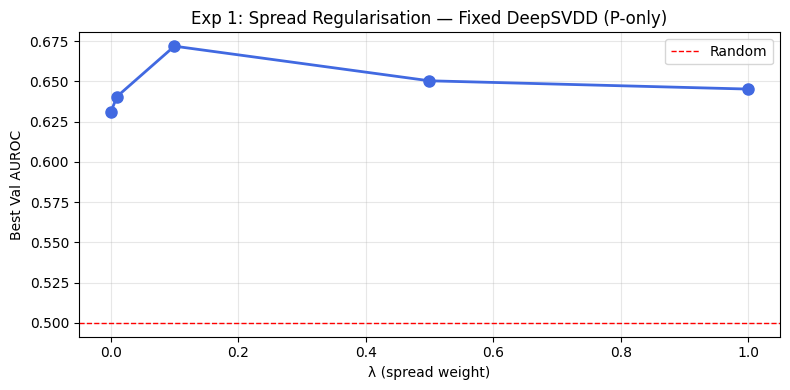

In [6]:
lambdas = [0.0, 0.01, 0.1, 0.5, 1.0]
spread_results = []

print('Experiment 1: Spread Regularisation (fixed model, W-only)')
print(f'  λ=0.0 = standard SVDD loss (baseline)\n')
for lam in lambdas:
    m = DeepSVDD(freeze_up_to='layer2', hidden_dims=[256], out_dim=64,
                 use_bn=False).to(DEVICE)
    if lam == 0.0:
        auroc = quick_train_eval(m, train_loader, val_loader)
    else:
        auroc = quick_train_eval_spread(m, train_loader, val_loader, lam=lam)
    spread_results.append({'lambda': lam, 'auroc': auroc})
    print(f'  λ={lam:.2f}  AUROC={auroc:.4f}')

best_spread = max(spread_results, key=lambda x: x['auroc'])
best_lambda = best_spread['lambda']
print(f'\nBest: λ={best_lambda}  AUROC={best_spread["auroc"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([r['lambda'] for r in spread_results],
        [r['auroc']  for r in spread_results],
        'o-', color='royalblue', lw=2, markersize=8)
ax.axhline(0.5, color='red', linestyle='--', lw=1, label='Random')
ax.set_xlabel('λ (spread weight)'); ax.set_ylabel('Best Val AUROC')
ax.set_title('Exp 1: Spread Regularisation — Fixed DeepSVDD (P-only)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'abl_spread.png'), dpi=120, bbox_inches='tight')
plt.show()

## Experiment 2 — Momentum Centre Update

```
c ← momentum * c + (1 - momentum) * mean(z_batch)
```

If weights drift toward 0, the centre follows → distances stay meaningful → loss doesn't collapse to 0.

Experiment 2: Momentum Centre Update (fixed model, P-only)
  momentum=1.0 = fixed centre (standard SVDD)



init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.51it/s]


  Centre initialised — mean norm: 1.5155
  momentum=0.999  AUROC=0.6272


init_centre: 100%|██████████| 238/238 [01:08<00:00,  3.49it/s]


  Centre initialised — mean norm: 1.3227
  momentum=0.99  AUROC=0.6477


init_centre: 100%|██████████| 238/238 [01:08<00:00,  3.49it/s]


  Centre initialised — mean norm: 1.4088
  momentum=0.9  AUROC=0.6301


init_centre: 100%|██████████| 238/238 [01:08<00:00,  3.48it/s]


  Centre initialised — mean norm: 1.6020
  momentum=0.5  AUROC=0.6678

Fixed centre baseline : AUROC=0.6307
Best momentum         : 0.5  AUROC=0.6678


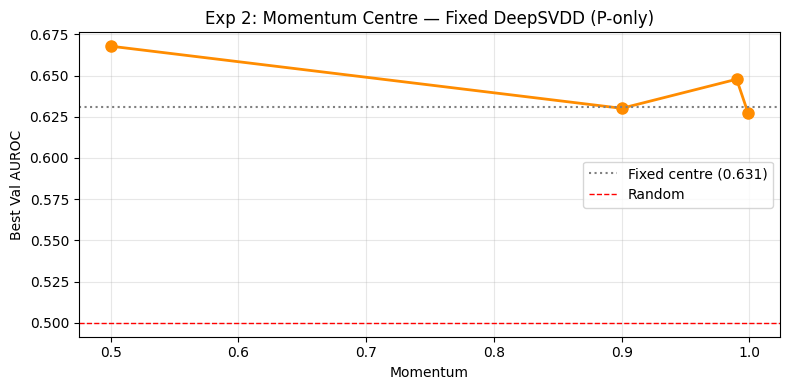

In [7]:
momentums = [0.999, 0.99, 0.9, 0.5]
momentum_results = []

print('Experiment 2: Momentum Centre Update (fixed model, P-only)')
print('  momentum=1.0 = fixed centre (standard SVDD)\n')
for m_val in momentums:
    m = DeepSVDD(freeze_up_to='layer2', hidden_dims=[256], out_dim=64,
                 use_bn=False).to(DEVICE)
    auroc = quick_train_eval_momentum(m, train_loader, val_loader, momentum=m_val)
    momentum_results.append({'momentum': m_val, 'auroc': auroc})
    print(f'  momentum={m_val}  AUROC={auroc:.4f}')

# Also compare to fixed centre baseline
baseline_auroc = spread_results[0]['auroc']   # λ=0 from Exp 1
best_momentum = max(momentum_results, key=lambda x: x['auroc'])
print(f'\nFixed centre baseline : AUROC={baseline_auroc:.4f}')
print(f'Best momentum         : {best_momentum["momentum"]}  AUROC={best_momentum["auroc"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([r['momentum'] for r in momentum_results],
        [r['auroc']    for r in momentum_results],
        'o-', color='darkorange', lw=2, markersize=8)
ax.axhline(baseline_auroc, color='grey', linestyle=':', lw=1.5,
           label=f'Fixed centre ({baseline_auroc:.3f})')
ax.axhline(0.5, color='red', linestyle='--', lw=1, label='Random')
ax.set_xlabel('Momentum'); ax.set_ylabel('Best Val AUROC')
ax.set_title('Exp 2: Momentum Centre — Fixed DeepSVDD (P-only)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'abl_momentum.png'), dpi=120, bbox_inches='tight')
plt.show()

## Experiment 3 — Freezing Strategy

Experiment 3: Freezing Strategy (fixed model, P-only)


init_centre: 100%|██████████| 238/238 [01:08<00:00,  3.48it/s]


  Centre initialised — mean norm: 1.5426
  Freeze to layer3           AUROC=0.6910


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.55it/s]


  Centre initialised — mean norm: 1.3484
  Freeze to layer2           AUROC=0.6585


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.55it/s]


  Centre initialised — mean norm: 1.5515
  Freeze to layer1           AUROC=0.6432


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.54it/s]


  Centre initialised — mean norm: 1.3042
  No freezing                AUROC=0.6077

Best: Freeze to layer3  AUROC=0.6910


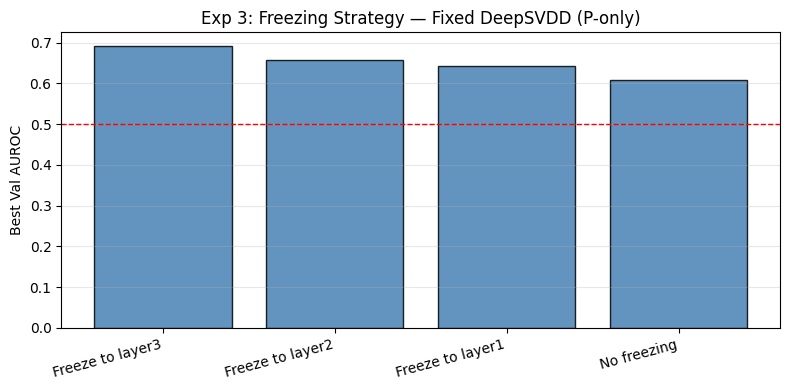

In [8]:
freeze_configs = [
    {'label': 'Freeze to layer3', 'freeze_up_to': 'layer3'},
    {'label': 'Freeze to layer2', 'freeze_up_to': 'layer2'},
    {'label': 'Freeze to layer1', 'freeze_up_to': 'layer1'},
    {'label': 'No freezing',      'freeze_up_to': None},
]
freeze_results = []

print('Experiment 3: Freezing Strategy (fixed model, P-only)')
for cfg in freeze_configs:
    m = DeepSVDD(freeze_up_to=cfg['freeze_up_to'], hidden_dims=[256],
                 out_dim=64, use_bn=False).to(DEVICE)
    auroc = quick_train_eval(m, train_loader, val_loader)
    freeze_results.append({**cfg, 'auroc': auroc})
    print(f'  {cfg["label"]:25s}  AUROC={auroc:.4f}')

best_freeze = max(freeze_results, key=lambda x: x['auroc'])
best_freeze_up_to = best_freeze['freeze_up_to']
print(f'\nBest: {best_freeze["label"]}  AUROC={best_freeze["auroc"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([r['label'] for r in freeze_results],
       [r['auroc']  for r in freeze_results],
       color='steelblue', edgecolor='black', alpha=0.85)
ax.axhline(0.5, color='red', linestyle='--', lw=1)
ax.set_ylabel('Best Val AUROC')
ax.set_title('Exp 3: Freezing Strategy — Fixed DeepSVDD (P-only)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'abl_freeze.png'), dpi=120, bbox_inches='tight')
plt.show()

## Experiment 4 — Head Architecture

Experiment 4: Head Architecture (fixed model, P-only)
  Note: use_bn=True excluded — known to cause collapse



init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.53it/s]


  Centre initialised — mean norm: 3.6507
  1-layer  (512→64)                    AUROC=0.6774


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.54it/s]


  Centre initialised — mean norm: 1.2622
  2-layer  (512→256→64)                AUROC=0.7105


...

  Centre initialised — mean norm: 1.4454
  2-layer + Drop(0.3)                  AUROC=0.6202


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.55it/s]


  Centre initialised — mean norm: 0.9084
  3-layer  (512→256→128→64)            AUROC=0.6609


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.54it/s]


  Centre initialised — mean norm: 0.8654
  3-layer + Drop(0.3)                  AUROC=0.5897

Best: 2-layer  (512→256→64)  AUROC=0.7105


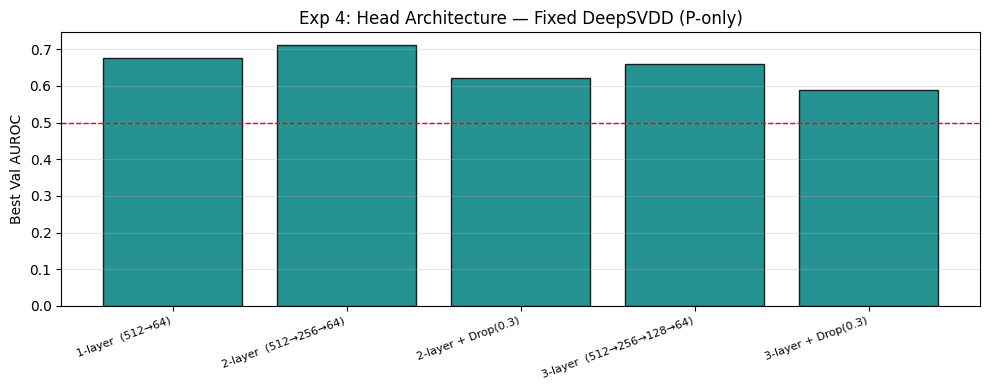

In [9]:
head_configs = [
    {'label': '1-layer  (512→64)',         'hidden_dims': [],         'use_bn': False, 'dropout': 0.0},
    {'label': '2-layer  (512→256→64)',      'hidden_dims': [256],      'use_bn': False, 'dropout': 0.0},
    {'label': '2-layer + Drop(0.3)',        'hidden_dims': [256],      'use_bn': False, 'dropout': 0.3},
    {'label': '3-layer  (512→256→128→64)', 'hidden_dims': [256, 128], 'use_bn': False, 'dropout': 0.0},
    {'label': '3-layer + Drop(0.3)',        'hidden_dims': [256, 128], 'use_bn': False, 'dropout': 0.3},
]
head_results = []

print('Experiment 4: Head Architecture (fixed model, P-only)')
print('  Note: use_bn=True excluded — known to cause collapse\n')
for cfg in head_configs:
    m = DeepSVDD(freeze_up_to=best_freeze_up_to,
                 hidden_dims=cfg['hidden_dims'], out_dim=64,
                 use_bn=cfg['use_bn'], dropout=cfg['dropout']).to(DEVICE)
    auroc = quick_train_eval(m, train_loader, val_loader)
    head_results.append({**cfg, 'auroc': auroc})
    print(f'  {cfg["label"]:35s}  AUROC={auroc:.4f}')

best_head = max(head_results, key=lambda x: x['auroc'])
best_head_cfg = best_head
print(f'\nBest: {best_head["label"]}  AUROC={best_head["auroc"]:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([r['label'] for r in head_results],
       [r['auroc']  for r in head_results],
       color='teal', edgecolor='black', alpha=0.85)
ax.axhline(0.5, color='red', linestyle='--', lw=1)
ax.set_ylabel('Best Val AUROC')
ax.set_title('Exp 4: Head Architecture — Fixed DeepSVDD (P-only)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'abl_head.png'), dpi=120, bbox_inches='tight')
plt.show()

## Experiment 5 — Bottleneck Dimension

Experiment 5: Bottleneck Dimension (fixed model, P-only)


init_centre: 100%|██████████| 238/238 [01:06<00:00,  3.55it/s]


  Centre initialised — mean norm: 0.6957
  out_dim= 16  AUROC=0.6784


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.55it/s]


  Centre initialised — mean norm: 1.1437
  out_dim= 32  AUROC=0.6620


...

  Centre initialised — mean norm: 1.3953
  out_dim= 64  AUROC=0.6577


init_centre: 100%|██████████| 238/238 [01:06<00:00,  3.55it/s]


  Centre initialised — mean norm: 2.2537
  out_dim=128  AUROC=0.6856


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.54it/s]


  Centre initialised — mean norm: 3.0679
  out_dim=256  AUROC=0.6893

Best: out_dim=256  AUROC=0.6893


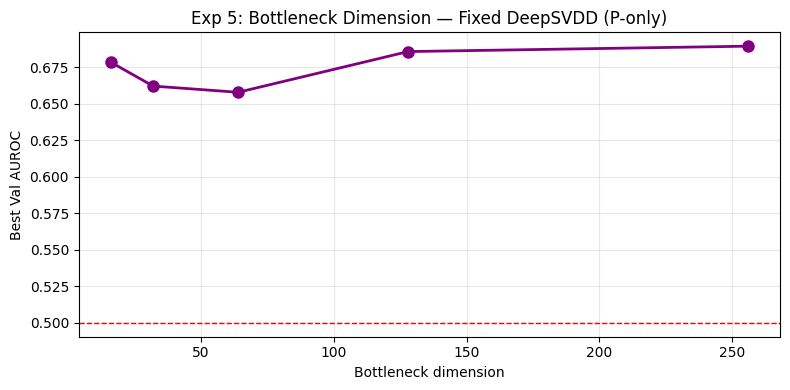

In [10]:
dim_configs = [16, 32, 64, 128, 256]
dim_results  = []

print('Experiment 5: Bottleneck Dimension (fixed model, P-only)')
for dim in dim_configs:
    m = DeepSVDD(freeze_up_to=best_freeze_up_to,
                 hidden_dims=best_head_cfg['hidden_dims'], out_dim=dim,
                 use_bn=False, dropout=best_head_cfg['dropout']).to(DEVICE)
    auroc = quick_train_eval(m, train_loader, val_loader)
    dim_results.append({'dim': dim, 'auroc': auroc})
    print(f'  out_dim={dim:3d}  AUROC={auroc:.4f}')

best_dim = max(dim_results, key=lambda x: x['auroc'])
best_out_dim = best_dim['dim']
print(f'\nBest: out_dim={best_out_dim}  AUROC={best_dim["auroc"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([r['dim'] for r in dim_results],
        [r['auroc'] for r in dim_results],
        'o-', color='purple', lw=2, markersize=8)
ax.axhline(0.5, color='red', linestyle='--', lw=1)
ax.set_xlabel('Bottleneck dimension'); ax.set_ylabel('Best Val AUROC')
ax.set_title('Exp 5: Bottleneck Dimension — Fixed DeepSVDD (P-only)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'abl_dim.png'), dpi=120, bbox_inches='tight')
plt.show()

## Experiment 6 — Training Hyperparameters

In [11]:
hp_grid = [
    {'lr': 1e-3,  'wd': 0,    'bs': 64,  'sched': 'cosine'},
    {'lr': 1e-4,  'wd': 0,    'bs': 64,  'sched': 'cosine'},
    {'lr': 1e-4,  'wd': 1e-5, 'bs': 64,  'sched': 'cosine'},
    {'lr': 1e-4,  'wd': 1e-4, 'bs': 64,  'sched': 'cosine'},
    {'lr': 1e-4,  'wd': 1e-3, 'bs': 64,  'sched': 'cosine'},
    {'lr': 1e-4,  'wd': 1e-4, 'bs': 32,  'sched': 'cosine'},
    {'lr': 1e-4,  'wd': 1e-4, 'bs': 128, 'sched': 'cosine'},
    {'lr': 1e-4,  'wd': 1e-4, 'bs': 64,  'sched': None},
    {'lr': 5e-5,  'wd': 1e-4, 'bs': 64,  'sched': 'cosine'},
]
hp_results = []

print('Experiment 6: Training Hyperparameters (fixed model, P-only)\n')
for cfg in hp_grid:
    tr, va = make_loaders('clahe', batch_size=cfg['bs'])
    m = DeepSVDD(freeze_up_to=best_freeze_up_to,
                 hidden_dims=best_head_cfg['hidden_dims'],
                 out_dim=best_out_dim, use_bn=False,
                 dropout=best_head_cfg['dropout']).to(DEVICE)
    auroc = quick_train_eval(m, tr, va, lr=cfg['lr'], wd=cfg['wd'],
                              scheduler_type=cfg['sched'])
    hp_results.append({**cfg, 'auroc': auroc})
    print(f"  lr={cfg['lr']:.0e}  wd={cfg['wd']:.0e}  bs={cfg['bs']:3d}  "
          f"sched={str(cfg['sched']):6s}  AUROC={auroc:.4f}")

best_hp = max(hp_results, key=lambda x: x['auroc'])
print(f'\nBest: lr={best_hp["lr"]:.0e}  wd={best_hp["wd"]:.0e}  '
      f'bs={best_hp["bs"]}  sched={best_hp["sched"]}  AUROC={best_hp["auroc"]:.4f}')

Experiment 6: Training Hyperparameters (fixed model, P-only)



init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.54it/s]


  Centre initialised — mean norm: 3.5410
  lr=1e-03  wd=0e+00  bs= 64  sched=cosine  AUROC=0.6004


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.55it/s]


  Centre initialised — mean norm: 3.2244
  lr=1e-04  wd=0e+00  bs= 64  sched=cosine  AUROC=0.6903


...

  Centre initialised — mean norm: 2.9415
  lr=1e-04  wd=1e-04  bs=128  sched=cosine  AUROC=0.6848


init_centre: 100%|██████████| 238/238 [01:08<00:00,  3.47it/s]


  Centre initialised — mean norm: 2.8765
  lr=1e-04  wd=1e-04  bs= 64  sched=None    AUROC=0.6875


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.51it/s]


  Centre initialised — mean norm: 3.0444
  lr=5e-05  wd=1e-04  bs= 64  sched=cosine  AUROC=0.6525

Best: lr=1e-04  wd=1e-03  bs=64  sched=cosine  AUROC=0.7138


## Experiment 7 — Preprocessing (CLAHE vs None)

In [12]:
prep_results = []
print('Experiment 7: Preprocessing (fixed model, P-only)')
for prep in ['clahe', 'none']:
    tr, va = make_loaders(prep, batch_size=best_hp['bs'])
    m = DeepSVDD(freeze_up_to=best_freeze_up_to,
                 hidden_dims=best_head_cfg['hidden_dims'],
                 out_dim=best_out_dim, use_bn=False,
                 dropout=best_head_cfg['dropout']).to(DEVICE)
    auroc = quick_train_eval(m, tr, va, lr=best_hp['lr'], wd=best_hp['wd'],
                              scheduler_type=best_hp['sched'])
    prep_results.append({'prep': prep, 'auroc': auroc})
    print(f'  {prep:6s}  AUROC={auroc:.4f}')

best_prep = max(prep_results, key=lambda x: x['auroc'])['prep']
print(f'\nBest preprocessing: {best_prep}')

Experiment 7: Preprocessing (fixed model, P-only)


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.55it/s]


  Centre initialised — mean norm: 2.9359
  clahe   AUROC=0.6727


init_centre: 100%|██████████| 238/238 [00:50<00:00,  4.73it/s]


  Centre initialised — mean norm: 2.8736
  none    AUROC=0.7028

Best preprocessing: none


## Experiment 8 — Cross-Entropy Noise Regularisation (Chong et al., 2021)

From *"Simple and Effective Prevention of Mode Collapse in Deep One-Class Classification"* (Chong et al., 2021).

The idea: inject random Gaussian noise samples and train the network to classify them as "not normal" via a cross-entropy term. This forces embeddings to stay spread out — if all normal embeddings collapse to the same point, the noise samples would also map there and the CE loss would spike.

**Combined loss:**
```
L = SVDD_loss + α · CE_loss(noise_logit, label=1)
```

Where:
- `noise_logit`: a small binary head scores each sample as normal (0) or noise (1)
- `α`: weight on the CE term (swept below)
- noise samples drawn from `N(0, 1)` — same shape as input images

Experiment 8: Cross-Entropy Noise Regularisation (Chong et al., 2021)
  α=0.0 = standard SVDD (no noise reg)



init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.55it/s]


  Centre initialised — mean norm: 1.5759
  α=0.00  AUROC=0.6693


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.53it/s]


  Centre initialised — mean norm: 1.5567
  α=0.01  AUROC=0.6557


...

  Centre initialised — mean norm: 1.4188
  α=0.10  AUROC=0.6280


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.52it/s]


  Centre initialised — mean norm: 1.7603
  α=0.50  AUROC=0.5673


init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.54it/s]


  Centre initialised — mean norm: 1.4236
  α=1.00  AUROC=0.5245

Best: α=0.0  AUROC=0.6693


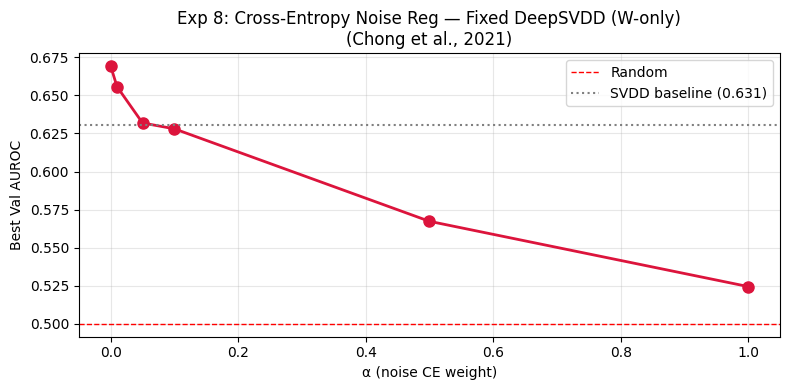

In [13]:
class SVDDWithNoiseReg(nn.Module):
    """
    Deep SVDD + cross-entropy noise regularisation (Chong et al., 2021).

    Adds a binary classification head on top of the SVDD embeddings.
    Normal samples are labelled 0, random Gaussian noise samples labelled 1.
    The CE loss prevents collapse: if z_normal ≈ z_noise, CE loss spikes.

    Architecture:
        ResNet-18 → ProjectionHead → z  (SVDD embedding, dim=out_dim)
                                     ↓
                               Linear(out_dim, 1)  (noise discriminator head)
    """

    def __init__(self, base_model: nn.Module, out_dim: int = 64):
        super().__init__()
        self.base = base_model          # DeepSVDD instance (fixed bugs)
        self.noise_head = nn.Linear(out_dim, 1, bias=True)

    def forward(self, x):
        return self.base(x)             # returns z — same as DeepSVDD

    def noise_logit(self, z):
        return self.noise_head(z).squeeze(1)   # (B,) binary logit

    @property
    def centre(self):
        return self.base.centre

    def anomaly_score(self, x):
        return self.base.anomaly_score(x)

    def init_centre(self, loader, device, eps=0.1):
        self.base.init_centre(loader, device, eps)


def quick_train_eval_noise(
    base_model, tr_loader, va_loader,
    alpha=0.1, lr=1e-4, wd=1e-4,
    n_epochs=QUICK_EPOCHS,
    device=DEVICE,
) -> float:
    """SVDD + CE noise regularisation — returns best val AUROC."""
    model = SVDDWithNoiseReg(base_model, out_dim=base_model.centre.shape[0]).to(device)
    model.init_centre(tr_loader, device)

    opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                     lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    ce_crit = nn.BCEWithLogitsLoss()

    best_auroc = 0.0
    for epoch in range(n_epochs):
        model.train()
        for x, _ in tr_loader:
            x = x.to(device)
            B = x.shape[0]

            # SVDD loss on normal samples
            z_normal = model(x)
            svdd_loss = ((z_normal - model.centre) ** 2).sum(dim=1).mean()

            # CE loss: normal=0, noise=1
            noise = torch.randn_like(x)          # N(0,1), same shape as images
            z_noise  = model(noise)
            logit_normal = model.noise_logit(z_normal)
            logit_noise  = model.noise_logit(z_noise)
            logits = torch.cat([logit_normal, logit_noise], dim=0)
            labels = torch.cat([
                torch.zeros(B, device=device),   # normal → 0
                torch.ones(B,  device=device),   # noise  → 1
            ])
            ce_loss = ce_crit(logits, labels)

            loss = svdd_loss + alpha * ce_loss
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()

        scores, labels_eval = eval_scores(model, va_loader, device)
        auroc = roc_auc_score(labels_eval, scores)
        best_auroc = max(best_auroc, auroc)
    return best_auroc


# ── Sweep α ────────────────────────────────────────────────────────────────
alphas = [0.0, 0.01, 0.05, 0.1, 0.5, 1.0]
noise_results = []

print('Experiment 8: Cross-Entropy Noise Regularisation (Chong et al., 2021)')
print('  α=0.0 = standard SVDD (no noise reg)\n')
for alpha in alphas:
    base = DeepSVDD(freeze_up_to='layer2', hidden_dims=[256], out_dim=64,
                    use_bn=False).to(DEVICE)
    if alpha == 0.0:
        auroc = quick_train_eval(base, train_loader, val_loader)
    else:
        auroc = quick_train_eval_noise(base, train_loader, val_loader, alpha=alpha)
    noise_results.append({'alpha': alpha, 'auroc': auroc})
    print(f'  α={alpha:.2f}  AUROC={auroc:.4f}')

best_noise = max(noise_results, key=lambda x: x['auroc'])
best_alpha = best_noise['alpha']
print(f'\nBest: α={best_alpha}  AUROC={best_noise["auroc"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([r['alpha'] for r in noise_results],
        [r['auroc']  for r in noise_results],
        'o-', color='crimson', lw=2, markersize=8)
ax.axhline(0.5, color='red', linestyle='--', lw=1, label='Random')
ax.axhline(spread_results[0]['auroc'], color='grey', linestyle=':', lw=1.5,
           label=f'SVDD baseline ({spread_results[0]["auroc"]:.3f})')
ax.set_xlabel('α (noise CE weight)'); ax.set_ylabel('Best Val AUROC')
ax.set_title('Exp 8: Cross-Entropy Noise Reg — Fixed DeepSVDD (W-only)\n(Chong et al., 2021)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'abl_noise_reg.png'), dpi=120, bbox_inches='tight')
plt.show()

## Experiment 9 — Adaptive Weighting (Chong et al., 2021)

Fixed α (Exp 8) is a manual trade-off. Chong et al. propose an adaptive scheme where α is automatically adjusted each epoch based on the ratio of the two losses:

```
α_t = SVDD_loss_t / reg_loss_t
```

When SVDD loss is large relative to reg loss → α increases (more regularisation needed).  
When SVDD loss is small (collapsed) → α decreases (reg takes over).  

This removes the need to hand-tune α. We test it with both regularisers:
- **Adaptive + Spread**: `L = SVDD - α_t · std(z)`
- **Adaptive + Noise CE**: `L = SVDD + α_t · CE`

Experiment 9: Adaptive Weighting (Chong et al., 2021)



init_centre: 100%|██████████| 238/238 [01:07<00:00,  3.54it/s]


  Centre initialised — mean norm: 1.5426
  Adaptive + Spread  AUROC=0.6597  (fixed best λ=0.1: 0.6718)


init_centre: 100%|██████████| 238/238 [01:08<00:00,  3.46it/s]


  Centre initialised — mean norm: 1.7322
  Adaptive + Noise   AUROC=0.4776  (fixed best α=0.0: 0.6693)


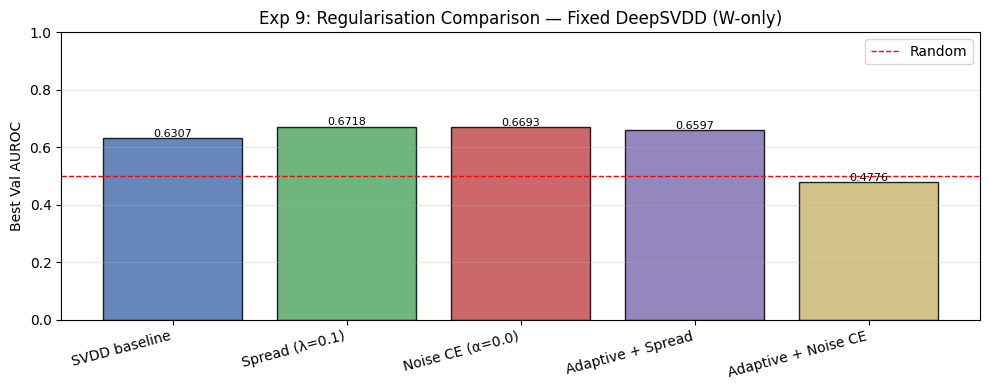


=== Regularisation Summary ===
  SVDD baseline        : 0.6307
  + Spread (fixed λ)   : 0.6718
  + Noise CE (fixed α) : 0.6693
  + Adaptive Spread    : 0.6597
  + Adaptive Noise CE  : 0.4776


In [14]:
def quick_train_eval_adaptive_spread(
    model, tr_loader, va_loader,
    lr=1e-4, wd=1e-4,
    n_epochs=QUICK_EPOCHS,
    device=DEVICE,
    eps=1e-8,
) -> float:
    """
    SVDD + adaptive spread regularisation.
    α_t = svdd_loss / spread_loss  (updated each epoch).
    Loss = SVDD - α_t · std(z)
    """
    model.init_centre(tr_loader, device)
    opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                     lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    alpha = 1.0   # initial α
    best_auroc = 0.0

    for epoch in range(n_epochs):
        model.train()
        epoch_svdd, epoch_spread = 0.0, 0.0
        for x, _ in tr_loader:
            x = x.to(device)
            z = model(x)
            svdd_loss  = ((z - model.centre) ** 2).sum(dim=1).mean()
            spread     = z.std(dim=0).mean()
            loss       = svdd_loss - alpha * spread
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_svdd  += svdd_loss.item()
            epoch_spread += spread.item()
        sched.step()

        # Update α based on epoch-level loss ratio
        mean_svdd   = epoch_svdd  / len(tr_loader)
        mean_spread = epoch_spread / len(tr_loader)
        alpha = mean_svdd / (mean_spread + eps)

        scores, labels = eval_scores(model, va_loader, device)
        auroc = roc_auc_score(labels, scores)
        best_auroc = max(best_auroc, auroc)
    return best_auroc


def quick_train_eval_adaptive_noise(
    base_model, tr_loader, va_loader,
    lr=1e-4, wd=1e-4,
    n_epochs=QUICK_EPOCHS,
    device=DEVICE,
    eps=1e-8,
) -> float:
    """
    SVDD + adaptive cross-entropy noise regularisation.
    α_t = svdd_loss / ce_loss  (updated each epoch).
    Loss = SVDD + α_t · CE
    """
    model = SVDDWithNoiseReg(base_model, out_dim=base_model.centre.shape[0]).to(device)
    model.init_centre(tr_loader, device)
    opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                     lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    ce_crit = nn.BCEWithLogitsLoss()

    alpha = 1.0
    best_auroc = 0.0

    for epoch in range(n_epochs):
        model.train()
        epoch_svdd, epoch_ce = 0.0, 0.0
        for x, _ in tr_loader:
            x = x.to(device)
            B = x.shape[0]

            z_normal  = model(x)
            svdd_loss = ((z_normal - model.centre) ** 2).sum(dim=1).mean()

            noise    = torch.randn_like(x)
            z_noise  = model(noise)
            logits   = torch.cat([model.noise_logit(z_normal),
                                  model.noise_logit(z_noise)], dim=0)
            targets  = torch.cat([torch.zeros(B, device=device),
                                  torch.ones(B,  device=device)])
            ce_loss  = ce_crit(logits, targets)

            loss = svdd_loss + alpha * ce_loss
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_svdd += svdd_loss.item()
            epoch_ce   += ce_loss.item()
        sched.step()

        mean_svdd = epoch_svdd / len(tr_loader)
        mean_ce   = epoch_ce   / len(tr_loader)
        alpha     = mean_svdd  / (mean_ce + eps)

        scores, labels = eval_scores(model, va_loader, device)
        auroc = roc_auc_score(labels, scores)
        best_auroc = max(best_auroc, auroc)
    return best_auroc


# ── Run Experiment 9 ────────────────────────────────────────────────────────
adaptive_results = {}

print('Experiment 9: Adaptive Weighting (Chong et al., 2021)\n')

# Adaptive + Spread
m = DeepSVDD(freeze_up_to='layer2', hidden_dims=[256], out_dim=64,
             use_bn=False).to(DEVICE)
auroc_adap_spread = quick_train_eval_adaptive_spread(m, train_loader, val_loader)
adaptive_results['Adaptive + Spread'] = auroc_adap_spread
print(f'  Adaptive + Spread  AUROC={auroc_adap_spread:.4f}  '
      f'(fixed best λ={best_lambda}: {best_spread["auroc"]:.4f})')

# Adaptive + Noise CE
base = DeepSVDD(freeze_up_to='layer2', hidden_dims=[256], out_dim=64,
                use_bn=False).to(DEVICE)
auroc_adap_noise = quick_train_eval_adaptive_noise(base, train_loader, val_loader)
adaptive_results['Adaptive + Noise CE'] = auroc_adap_noise
print(f'  Adaptive + Noise   AUROC={auroc_adap_noise:.4f}  '
      f'(fixed best α={best_alpha}: {best_noise["auroc"]:.4f})')

# Comparison bar chart
fig, ax = plt.subplots(figsize=(10, 4))
labels_chart = ['SVDD baseline',
                f'Spread (λ={best_lambda})',
                f'Noise CE (α={best_alpha})',
                'Adaptive + Spread',
                'Adaptive + Noise CE']
aurocs_chart = [spread_results[0]['auroc'],
                best_spread['auroc'],
                best_noise['auroc'],
                auroc_adap_spread,
                auroc_adap_noise]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
bars = ax.bar(labels_chart, aurocs_chart, color=colors, edgecolor='black', alpha=0.85)
ax.axhline(0.5, color='red', linestyle='--', lw=1, label='Random')
for bar, v in zip(bars, aurocs_chart):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.4f}',
            ha='center', fontsize=8)
ax.set_ylim(0, 1)
ax.set_ylabel('Best Val AUROC')
ax.set_title('Exp 9: Regularisation Comparison — Fixed DeepSVDD (W-only)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'abl_adaptive.png'), dpi=120, bbox_inches='tight')
plt.show()

print('\n=== Regularisation Summary ===')
print(f'  SVDD baseline        : {spread_results[0]["auroc"]:.4f}')
print(f'  + Spread (fixed λ)   : {best_spread["auroc"]:.4f}')
print(f'  + Noise CE (fixed α) : {best_noise["auroc"]:.4f}')
print(f'  + Adaptive Spread    : {auroc_adap_spread:.4f}')
print(f'  + Adaptive Noise CE  : {auroc_adap_noise:.4f}')

## Final — Best Config Summary & Full Training

In [15]:
print('=== Best Configuration Found ===')
print(f'  freeze_up_to  : {best_freeze_up_to}')
print(f'  hidden_dims   : {best_head_cfg["hidden_dims"]}')
print(f'  out_dim       : {best_out_dim}')
print(f'  dropout       : {best_head_cfg["dropout"]}')
print(f'  lr            : {best_hp["lr"]:.0e}')
print(f'  weight_decay  : {best_hp["wd"]:.0e}')
print(f'  batch_size    : {best_hp["bs"]}')
print(f'  scheduler     : {best_hp["sched"]}')
print(f'  preprocessing : {best_prep}')
print(f'  spread λ      : {best_lambda}')
print(f'  momentum      : {best_momentum["momentum"]}')

# ── Full training with best config ─────────────────────────────────────────
from src.train_utils import train_svdd_epoch, calibrate_threshold, compute_metrics, print_metrics
from sklearn.metrics import roc_auc_score

MAX_EPOCHS = 50
PATIENCE   = 7

final_tr, final_va = make_loaders(best_prep, batch_size=best_hp['bs'])
test_ds  = CrackDataset(test_records, preprocessing=best_prep)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

final_model = DeepSVDD(
    freeze_up_to = best_freeze_up_to,
    hidden_dims  = best_head_cfg['hidden_dims'],
    out_dim      = best_out_dim,
    use_bn       = False,
    dropout      = best_head_cfg['dropout'],
).to(DEVICE)
final_model.init_centre(final_tr, DEVICE)

opt   = optim.Adam(filter(lambda p: p.requires_grad, final_model.parameters()),
                   lr=best_hp['lr'], weight_decay=best_hp['wd'])
sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS) \
        if best_hp['sched'] == 'cosine' else None

best_auroc, no_improve = 0.0, 0
train_losses, val_aurocs = [], []

print(f'\nFull training (max {MAX_EPOCHS} epochs, patience={PATIENCE})...')
for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss = train_svdd_epoch(final_model, final_tr, opt, DEVICE)
    if sched: sched.step()
    train_losses.append(tr_loss)

    scores, labels = eval_scores(final_model, final_va, DEVICE)
    auroc = roc_auc_score(labels, scores)
    val_aurocs.append(auroc)

    marker = ' *' if auroc > best_auroc else ''
    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f'  Epoch {epoch:3d}  loss={tr_loss:.6f}  val_AUROC={auroc:.4f}{marker}')

    if auroc > best_auroc:
        best_auroc = auroc
        no_improve = 0
        torch.save({'model_state': final_model.state_dict()},
                   os.path.join(CKPT_DIR, 'svdd_ablation_best.pt'))
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'  Early stop at epoch {epoch}.')
            break

print(f'\nBest val AUROC: {best_auroc:.4f}')

# ── Test evaluation ────────────────────────────────────────────────────────
ckpt = torch.load(os.path.join(CKPT_DIR, 'svdd_ablation_best.pt'),
                   map_location=DEVICE, weights_only=True)
final_model.load_state_dict(ckpt['model_state'])

val_scores, val_labels = eval_scores(final_model, final_va, DEVICE)
tau, _ = calibrate_threshold(val_scores, val_labels)
test_scores, test_labels = eval_scores(final_model, test_loader, DEVICE)
metrics_final = compute_metrics(test_scores, test_labels, tau)

print('\n=== Fixed DeepSVDD — Best Ablation Config — Test Results ===')
print_metrics(metrics_final, 'DeepSVDD (ablation best)')

=== Best Configuration Found ===
  freeze_up_to  : layer3
  hidden_dims   : [256]
  out_dim       : 256
  dropout       : 0.0
  lr            : 1e-04
  weight_decay  : 1e-03
  batch_size    : 64
  scheduler     : cosine
  preprocessing : none
  spread λ      : 0.1
  momentum      : 0.5


init_centre: 100%|██████████| 238/238 [00:50<00:00,  4.73it/s]


  Centre initialised — mean norm: 3.2015

Full training (max 50 epochs, patience=7)...
  Epoch   1  loss=0.336976  val_AUROC=0.5961 *
  Epoch   2  loss=0.010264  val_AUROC=0.6089 *
  Epoch   3  loss=0.006034  val_AUROC=0.6090 *
  Epoch   4  loss=0.004026  val_AUROC=0.6120 *
  Epoch   5  loss=0.003253  val_AUROC=0.6253 *
  Epoch   6  loss=0.002511  val_AUROC=0.6328 *
  Epoch   9  loss=0.001916  val_AUROC=0.6422 *
  Epoch  10  loss=0.001509  val_AUROC=0.6350
  Epoch  15  loss=0.000877  val_AUROC=0.6133
  Early stop at epoch 16.

Best val AUROC: 0.6422

=== Fixed DeepSVDD — Best Ablation Config — Test Results ===
[DeepSVDD (ablation best)] AUROC: 0.6350  AUPRC: 0.1596  F1: 0.2495
  Confusion matrix:
    TN=  2234  FP=  1026
    FN=   189  TP=   202


In [19]:
# Cleanup GPU memory
import torch
torch.cuda.empty_cache()
print('GPU cache cleared.')


GPU cache cleared.


## Issues and Results
The SVDD ablation tested several ways to reduce collapse, including spread regularisation, momentum centre updates, freezing depth, projection head design, bottleneck size, training hyperparameters, preprocessing, and two Chong et al. (2021) regularisation variants. The best validation results from the quick ablations were obtained with freeze_up_to='layer3' (0.6910), out_dim=256 (0.6893), spread regularisation with λ=0.1 (0.6718), centre momentum 0.5 (0.6678), and training hyperparameters lr=1e-4, wd=1e-3, bs=64, cosine scheduler (0.7138). Raw images (none) outperformed CLAHE (0.7028 vs 0.6727). Noise-based regularisation did not help, and adaptive weighting was unstable.

However, when the best ablation settings were combined and trained fully, performance dropped back to a best validation AUROC of 0.6422 and a test AUROC of 0.6350 (AUPRC=0.1596, F1=0.2495). The final confusion matrix was TN=2234, FP=1026, FN=189, TP=202.

The main finding is that the ablations improved validation AUROC in isolation but did not generalise when combined. This indicates that the model was overfitting to hyperparameter choices rather than fixing the underlying optimisation problem.


> Hence we did not continue pushing SVDD further and instead moved to methods with a stronger inductive fit for localised anomalies like Student-Teacher and Prototypical Network